feature engineering

In [26]:
from pathlib import Path
import pandas as pd
from IPython.display import display

import holidays
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [20]:
df_demand = pd.read_csv(
    "data/clean/SvK/SE3/consumption_2018_2026_SE3.csv",
    index_col="datetime",
    parse_dates=["datetime"],
).sort_index()

# exclude the se3_metered_consumption_over_50mw
consumption_columns = [
    "se3_metered_consumption_excluding_interruptible_load",
    "se3_interruptible_load",
    "se3_profiled_supply_consumption",
    "se3_energy_storage_consumption",
]

df_demand["total_consumption"] = df_demand[consumption_columns].sum(
    axis=1,
    # min_count=len(consumption_columns),
)

df_demand = df_demand[["total_consumption"]]

print("Shape:", df_demand.shape)
print("Time range:", df_demand.index.min(), "→", df_demand.index.max())
print("Columns:", df_demand.columns.tolist())
df_demand.head()

Shape: (74472, 1)
Time range: 2018-01-01 00:00:00 → 2026-06-30 23:00:00
Columns: ['total_consumption']


,total_consumption
datetime,
2018-01-01 00:00:00,-9264.100956
2018-01-01 01:00:00,-9087.257656
2018-01-01 02:00:00,-8918.981208
2018-01-01 03:00:00,-8744.758445
2018-01-01 04:00:00,-8651.463840


In [28]:
df_weather = pd.read_csv(
    "data/clean/weather/era5_land_stockholm_2018_2026_merged.csv",
    index_col="valid_time",
    parse_dates=["valid_time"],
).sort_index()

df_weather = df_weather.drop(columns=['longitude', 'latitude'], errors='ignore')

print("Shape:", df_weather.shape)
print("Time range:", df_weather.index.min(), "→", df_weather.index.max())
print("Columns:", df_weather.columns.tolist())
df_weather.head()

Shape: (75984, 19)
Time range: 2018-01-01 00:00:00 → 2026-09-01 23:00:00
Columns: ['d2m', 't2m', 'sp', 'tp', 'ssrd', 'strd', 'skt', 'snowc', 'sde', 'stl1', 'stl2', 'stl3', 'stl4', 'swvl1', 'swvl2', 'swvl3', 'swvl4', 'u10', 'v10']


,d2m,t2m,sp,tp,ssrd,strd,skt,snowc,sde,stl1,stl2,stl3,stl4,swvl1,swvl2,swvl3,swvl4,u10,v10
valid_time,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,274.55210,274.60410,98839.970,0.000831,0.0,1117816.0,274.59183,2.685547,0.003906,275.19885,275.66718,276.66235,279.95230,0.437057,0.428635,0.427429,0.397156,-1.527222,4.483948
2018-01-01 01:00:00,274.80950,274.87103,98771.016,0.000382,0.0,1141575.8,274.84357,4.501953,0.004883,275.26820,275.66210,276.66278,279.94977,0.438995,0.429108,0.427414,0.397186,-1.044571,4.526154
2018-01-01 02:00:00,274.99918,275.49158,98715.220,0.000123,0.0,1152540.2,275.19415,4.488281,0.004883,275.38885,275.66090,276.66320,279.94727,0.438034,0.429581,0.427414,0.397217,-0.192734,4.067978
2018-01-01 03:00:00,275.46826,275.94240,98677.484,0.000017,0.0,1158140.5,275.58902,4.382812,0.004883,275.54340,275.67346,276.66553,279.94476,0.436600,0.429932,0.427399,0.397232,0.302444,3.289032
2018-01-01 04:00:00,275.81310,276.13544,98605.945,0.000002,0.0,1159660.5,275.88733,4.263672,0.003906,275.67914,275.69385,276.66580,279.94226,0.435364,0.430191,0.427383,0.397263,0.421661,2.628952


In [29]:
# Check whether weather covers every electricity timestamp
missing_weather = df_demand.index.difference(df_weather.index)

print("Electricity timestamps missing from weather:", len(missing_weather))
print(missing_weather[:10])

if len(missing_weather):
    raise ValueError("Resolve missing weather timestamps before alignment.")

# Select matching timestamps, in the same order; retain full weather separately
df_weather_aligned = df_weather.loc[df_demand.index].copy()

# Verify all four indices match exactly
assert df_demand.index.equals(df_weather_aligned.index)

df_combined = pd.concat(
    [df_demand, df_weather_aligned],
    axis=1,
    join="inner",
).sort_index()

print("Combined DataFrame Head:")
print(df_combined.head())

print("Combined DataFrame Shape:")
print(df_combined.shape)

if df_combined.index.equals(df_demand.index):
    print("The indices of df_combined and df_demand match.")
else:
    print("The indices of df_combined and df_demand do not match.")


Electricity timestamps missing from weather: 0
DatetimeIndex([], dtype='datetime64[us]', freq=None)
Combined DataFrame Head:
                     total_consumption  hour  day  weekday  month  \
datetime                                                            
2018-01-31 00:00:00      -10035.932560     0   31        2      1   
2018-01-31 01:00:00       -9942.362369     1   31        2      1   
2018-01-31 02:00:00       -9896.509094     2   31        2      1   
2018-01-31 03:00:00       -9952.570340     3   31        2      1   
2018-01-31 04:00:00      -10116.306108     4   31        2      1   

                           lag_24       lag_48       lag_168       lag_336  \
datetime                                                                     
2018-01-31 00:00:00 -10114.138907 -9360.312761 -10465.624545 -10146.994847   
2018-01-31 01:00:00  -9948.589970 -9267.181754 -10252.483859  -9963.767416   
2018-01-31 02:00:00  -9881.731966 -9297.904463 -10174.303069  -9863.781051   
2

In [30]:
# time-series feature engineering

# Basic time features
df_combined['hour'] = df_combined.index.hour
df_combined['day'] = df_combined.index.day
df_combined['weekday'] = df_combined.index.weekday
df_combined['month'] = df_combined.index.month

# Lag features for total_demand
# Since we are trying to predict day-ahead demand, so we use lags that correspond to 1 day, 2 days, 1 week, 2 weeks, and 1 month.
for lag in [24, 48, 168, 336, 720]:
    df_combined[f'lag_{lag}'] = df_combined['total_consumption'].shift(lag)

# Cyclical encodings
df_combined['hour_sin'] = np.sin(2 * np.pi * df_combined['hour'] / 24)
df_combined['hour_cos'] = np.cos(2 * np.pi * df_combined['hour'] / 24)
df_combined['month_sin'] = np.sin(2 * np.pi * df_combined['month'] / 12)
df_combined['month_cos'] = np.cos(2 * np.pi * df_combined['month'] / 12)

# Flags
df_combined['is_weekend'] = df_combined['weekday'].isin([5, 6]).astype(int)
df_combined['is_winter'] = df_combined['month'].isin([12, 1, 2]).astype(int)
df_combined['is_summer'] = df_combined['month'].isin([6, 7, 8]).astype(int)

swedish_holidays = holidays.Sweden(years=[2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026])
df_combined["is_holiday"] = (
    pd.Series(df_combined.index.date, index=df_combined.index)
    .isin(swedish_holidays)
    .astype(int)
)

# Drop rows with any missing values from shifting/rolling
df_combined.dropna(inplace=True)

# Print final checks
print("Shape:", df_combined.shape)
print("Date Range:", df_combined.index.min(), "to", df_combined.index.max())
print("Columns:", df_combined.columns.tolist())
print("Missing values:\n", df_combined.isna().sum())

print('is holiday:', df_combined['is_holiday'].value_counts(dropna=False))

df_combined.head()


Shape: (73032, 37)
Date Range: 2018-03-02 00:00:00 to 2026-06-30 23:00:00
Columns: ['total_consumption', 'hour', 'day', 'weekday', 'month', 'lag_24', 'lag_48', 'lag_168', 'lag_336', 'lag_720', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_winter', 'is_summer', 'is_holiday', 'd2m', 't2m', 'sp', 'tp', 'ssrd', 'strd', 'skt', 'snowc', 'sde', 'stl1', 'stl2', 'stl3', 'stl4', 'swvl1', 'swvl2', 'swvl3', 'swvl4', 'u10', 'v10']
Missing values:
 total_consumption    0
hour                 0
day                  0
weekday              0
month                0
lag_24               0
lag_48               0
lag_168              0
lag_336              0
lag_720              0
hour_sin             0
hour_cos             0
month_sin            0
month_cos            0
is_weekend           0
is_winter            0
is_summer            0
is_holiday           0
d2m                  0
t2m                  0
sp                   0
tp                   0
ssrd                 0
strd      

,total_consumption,hour,day,weekday,month,lag_24,lag_48,lag_168,lag_336,lag_720,...,stl1,stl2,stl3,stl4,swvl1,swvl2,swvl3,swvl4,u10,v10
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-02 00:00:00,-12544.564998,0,2,4,3,-13257.240654,-13263.320839,-11294.428976,-10540.212149,-10035.932560,...,272.51263,273.02136,274.10846,276.40770,0.394196,0.398514,0.414612,0.417480,-2.899322,-2.517242
2018-03-02 01:00:00,-12425.194829,1,2,4,3,-13029.870874,-13299.041832,-11038.679210,-10329.114319,-9942.362369,...,272.51290,273.01978,274.10614,276.40607,0.394165,0.398483,0.414597,0.417480,-2.992996,-2.600937
2018-03-02 02:00:00,-12370.363065,2,2,4,3,-12983.858264,-13203.492430,-10889.995697,-10207.576585,-9896.509094,...,272.51544,273.01813,274.10570,276.40240,0.394135,0.398468,0.414566,0.417465,-3.089279,-2.553818
2018-03-02 03:00:00,-12385.286108,3,2,4,3,-13043.411342,-13309.504605,-10903.626505,-10184.771938,-9952.570340,...,272.51654,273.01843,274.10526,276.40076,0.394104,0.398438,0.414536,0.417465,-3.414139,-2.331518
2018-03-02 04:00:00,-12585.546602,4,2,4,3,-13189.221355,-13495.387456,-11080.255545,-10304.321212,-10116.306108,...,272.51825,273.01678,274.10480,276.39905,0.394074,0.398407,0.414505,0.417465,-3.589371,-2.193220


,total_consumption,hour,day,weekday,month,lag_24,lag_48,lag_168,lag_336,lag_720,...,stl1,stl2,stl3,stl4,swvl1,swvl2,swvl3,swvl4,u10,v10
total_consumption,1.000000,-1.669300e-01,3.907663e-02,1.684467e-01,1.984294e-01,0.943582,0.885085,0.913957,0.869925,0.716384,...,0.753833,0.780178,0.702088,0.277856,-0.509545,-0.577194,-0.581997,-0.005336,-0.003805,0.143779
hour,-0.166930,1.000000e+00,7.834513e-18,2.669700e-19,-1.445495e-16,-0.166659,-0.166344,-0.165747,-0.165476,-0.164484,...,0.053494,0.021389,0.000228,0.000137,-0.005688,-0.003248,-0.001074,-0.000355,-0.024957,0.056722
day,0.039077,7.834513e-18,1.000000e+00,1.890725e-03,9.436073e-03,0.034353,0.033209,0.021887,-0.008465,0.046157,...,0.031835,0.030840,0.024062,0.012001,-0.049515,-0.040558,-0.014511,-0.008641,0.022645,-0.017003
weekday,0.168447,2.669700e-19,1.890725e-03,1.000000e+00,-1.129385e-03,0.012817,-0.144191,0.167680,0.167224,-0.141453,...,0.002970,0.002218,-0.000475,-0.000475,-0.002670,0.001587,0.000726,0.000491,0.019353,0.004304
month,0.198429,-1.445495e-16,9.436073e-03,-1.129385e-03,1.000000e+00,0.204213,0.210733,0.245203,0.302992,0.459967,...,0.276816,0.330524,0.492740,0.753210,-0.110908,-0.186842,-0.483791,-0.600566,0.007413,0.070530
lag_24,0.943582,-1.666587e-01,3.435300e-02,1.281704e-02,2.042134e-01,1.000000,0.943758,0.886326,0.841568,0.761612,...,0.749317,0.784546,0.712430,0.291526,-0.512408,-0.578354,-0.586533,-0.016844,-0.015701,0.092036
lag_48,0.885085,-1.663439e-01,3.320853e-02,-1.441914e-01,2.107331e-01,0.943758,1.000000,0.853439,0.807151,0.801353,...,0.741576,0.782092,0.721358,0.305188,-0.515772,-0.581762,-0.591268,-0.028377,-0.030317,0.073220
lag_168,0.913957,-1.657467e-01,2.188697e-02,1.676800e-01,2.452027e-01,0.886326,0.853439,1.000000,0.914392,0.759527,...,0.723541,0.773939,0.749535,0.371431,-0.522688,-0.596406,-0.619662,-0.083688,-0.028407,0.060209
lag_336,0.869925,-1.654760e-01,-8.465441e-03,1.672236e-01,3.029919e-01,0.841568,0.807151,0.914392,1.000000,0.791818,...,0.703883,0.761122,0.767534,0.457172,-0.512935,-0.595709,-0.654705,-0.160878,-0.031018,0.071844
lag_720,0.716384,-1.644843e-01,4.615684e-02,-1.414531e-01,4.599667e-01,0.761612,0.801353,0.759527,0.791818,1.000000,...,0.656245,0.723636,0.777867,0.618864,-0.439510,-0.534828,-0.683209,-0.329209,-0.034567,0.082686


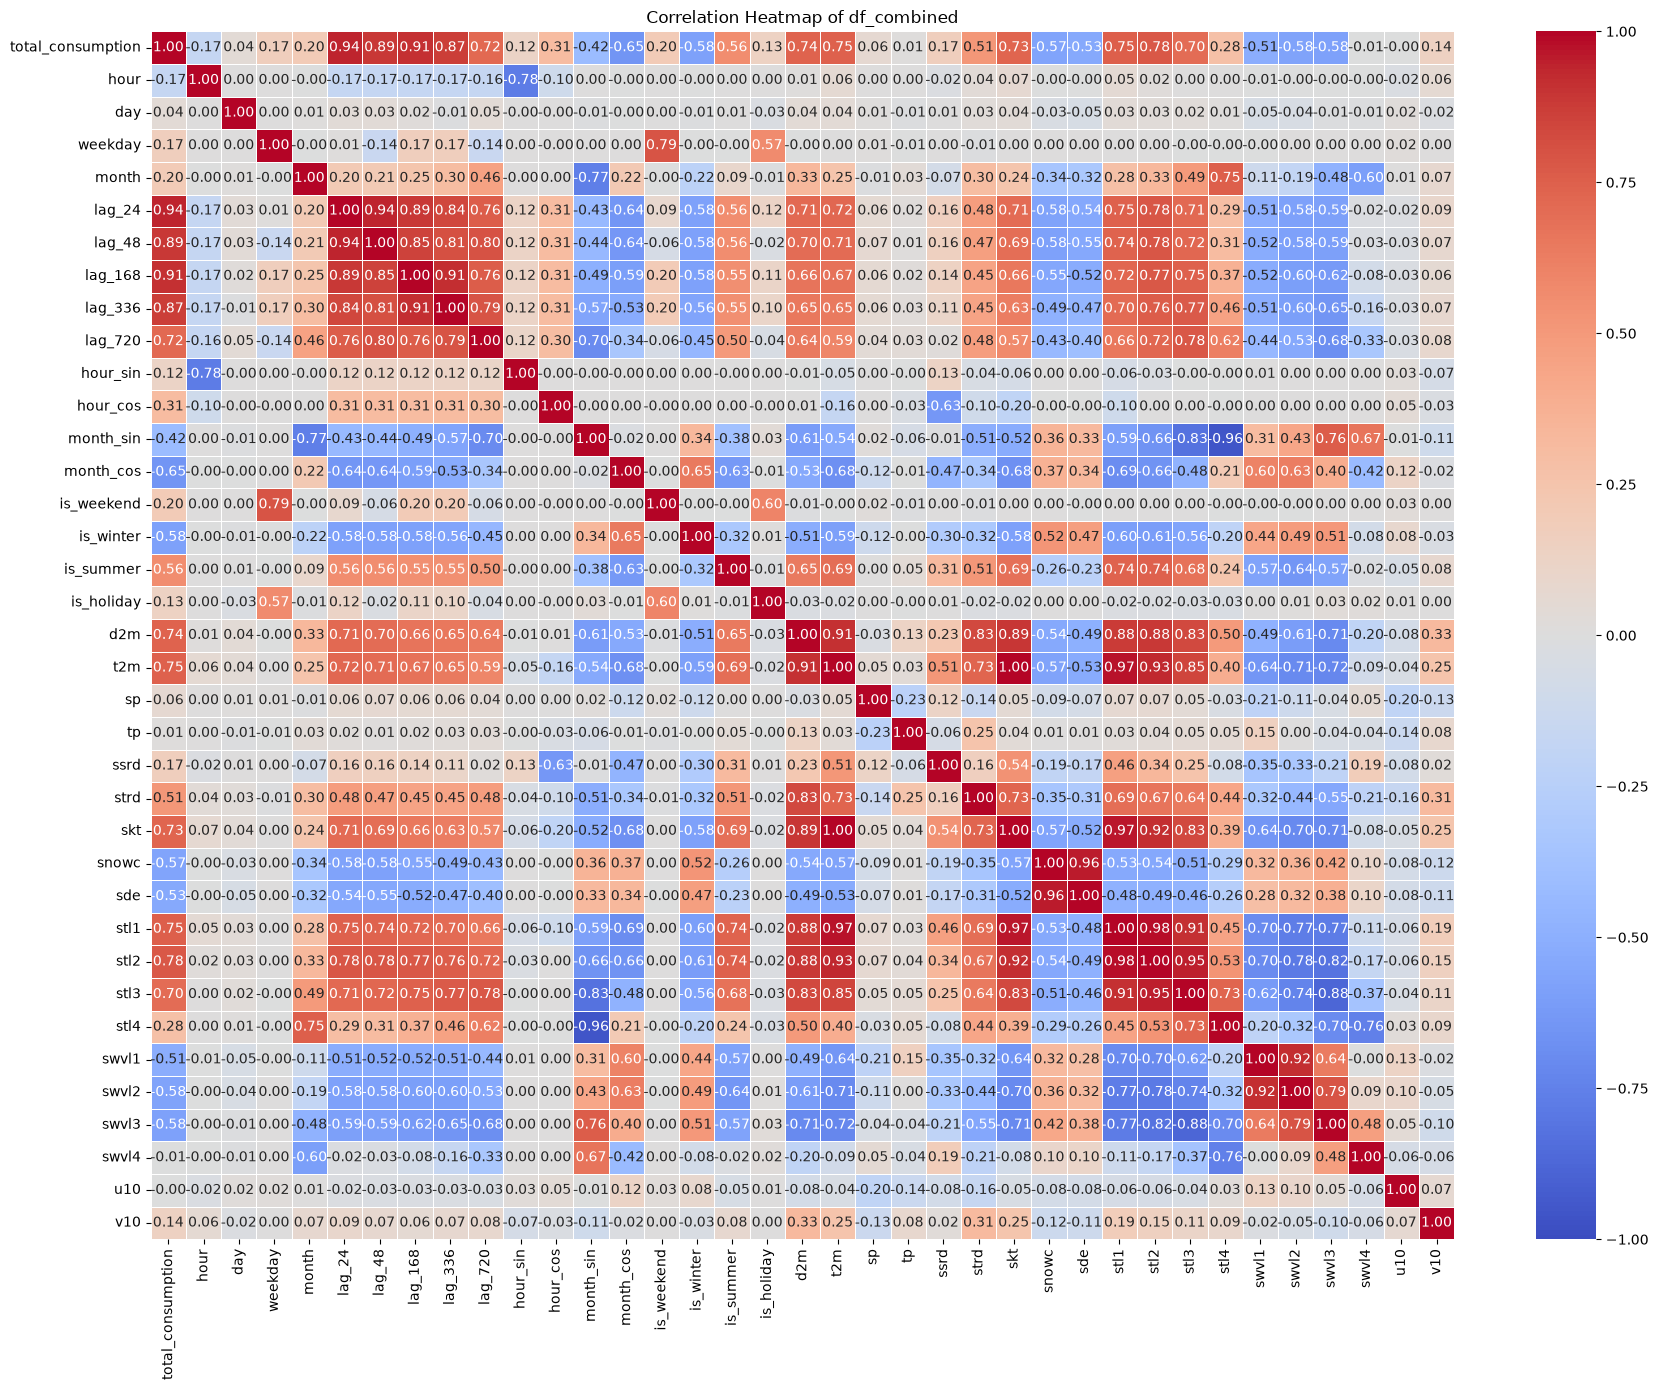

In [31]:
# Select only numeric columns
numeric_df = df_combined.select_dtypes(include="number")

# Calculate correlations
correlation_matrix = numeric_df.corr()

# Display correlations
display(correlation_matrix)

# Plot heatmap
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of df_combined")
plt.tight_layout()
plt.show()

### Feature Selection

After preliminary feature screening based on **domain relevance, forecast-time availability, and correlation analysis**, the remaining candidate features are evaluated using **5-fold time-series cross-validation**.

Features are evaluated in meaningful groups, such as temperature, humidity, wind, precipitation, solar radiation, and additional lag features. The objective is to identify a feature subset that minimizes the average validation error while avoiding unnecessary or redundant predictors.

The final test set is excluded from the entire feature-selection process.

In [32]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

selected_weather_features = [
    "t2m",  # 2-meter temperature
    "d2m",  # 2-meter dew point
    "u10",  # 10-meter U wind component
    "v10",  # 10-meter V wind component
    "ssrd", # Surface solar radiation downwards
    "tp",   # Total precipitation
    "snowc" # Snow cover
]

selected_calendar_features = [
    # "hour", using he cyclical encoding instead
    "day",
    "weekday",
    "month",
    "hour_sin",
    "hour_cos",
    # "month_sin",
    # "month_cos",
    "is_weekend",
    "is_holiday",
]

selected_lag_features = [
    "lag_24",  # 1 day lag
    "lag_48",  # 2 days lag
    "lag_168", # 1 week lag
    "lag_336", # 2 weeks lag
]

selected_features = selected_weather_features + selected_calendar_features + selected_lag_features
df_selected = df_combined[selected_features+["total_consumption"]]
print(df_selected.head())
print(df_selected.info())
print(df_selected.shape)

df_selected.to_csv("data/training/selected_features.csv")


                           t2m        d2m       u10       v10  ssrd  \
datetime                                                              
2018-03-02 00:00:00  266.69897  263.39282 -2.899322 -2.517242   0.0   
2018-03-02 01:00:00  266.90857  263.39297 -2.992996 -2.600937   0.0   
2018-03-02 02:00:00  267.09784  263.54614 -3.089279 -2.553818   0.0   
2018-03-02 03:00:00  267.33673  263.71246 -3.414139 -2.331518   0.0   
2018-03-02 04:00:00  267.49707  263.83014 -3.589371 -2.193220   0.0   

                               tp  snowc  day  weekday  month  hour_sin  \
datetime                                                                  
2018-03-02 00:00:00  9.685755e-07  100.0    2        4      3  0.000000   
2018-03-02 01:00:00  3.520399e-07  100.0    2        4      3  0.258819   
2018-03-02 02:00:00  4.526228e-07  100.0    2        4      3  0.500000   
2018-03-02 03:00:00  9.052455e-07  100.0    2        4      3  0.707107   
2018-03-02 04:00:00  1.177192e-06  100.0    2       